In [1]:
import pandas as pd
import numpy as np

from analyze_src.basic_data_inspection import DataInspector, DataTypesInspectionStrategy, SummaryStatisticsInspectionStrategy
from analyze_src.missing_values_analysis import SimpleMissingValuesAnalysis
from analyze_src.univariate_analysis import UnivariateAnalyzer, NumericalUnivariateAnalysis, CategoricalUnivariateAnalysis
from analyze_src.bivariate_analysis import BivariateAnalyzer, NumericalVsNumericalAnalysis, CategoricalVsNumericalAnalysis
from analyze_src.multivariate_analysis import SimpleMultivariateAnalysis

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Load the data
# Assuming you have already extracted the data into the 'extracted-data' folder

data_path = '../extracted_data/Bank Customer Churn Prediction.csv'
df = pd.read_csv(data_path)

In [3]:
# Step 1: Basic Data Inspection
# ------------------------------------
# Initialize the Data Inspector with a strategy for Data Types Inspection
data_inspector = DataInspector(DataTypesInspectionStrategy())
data_inspector.execute_inspection(df)


Data Types and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB
None


In [4]:
# Switch strategy to Summary Statistics Inspection
data_inspector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inspector.execute_inspection(df)


Summary Statistics (Numerical Features):
        customer_id  credit_score           age        tenure        balance  \
count  1.000000e+04  10000.000000  10000.000000  10000.000000   10000.000000   
mean   1.569094e+07    650.528800     38.921800      5.012800   76485.889288   
std    7.193619e+04     96.653299     10.487806      2.892174   62397.405202   
min    1.556570e+07    350.000000     18.000000      0.000000       0.000000   
25%    1.562853e+07    584.000000     32.000000      3.000000       0.000000   
50%    1.569074e+07    652.000000     37.000000      5.000000   97198.540000   
75%    1.575323e+07    718.000000     44.000000      7.000000  127644.240000   
max    1.581569e+07    850.000000     92.000000     10.000000  250898.090000   

       products_number  credit_card  active_member  estimated_salary  \
count     10000.000000  10000.00000   10000.000000      10000.000000   
mean          1.530200      0.70550       0.515100     100090.239881   
std           0.58165


Missing Values Count by Column:
Series([], dtype: int64)

Visualizing Missing Values...


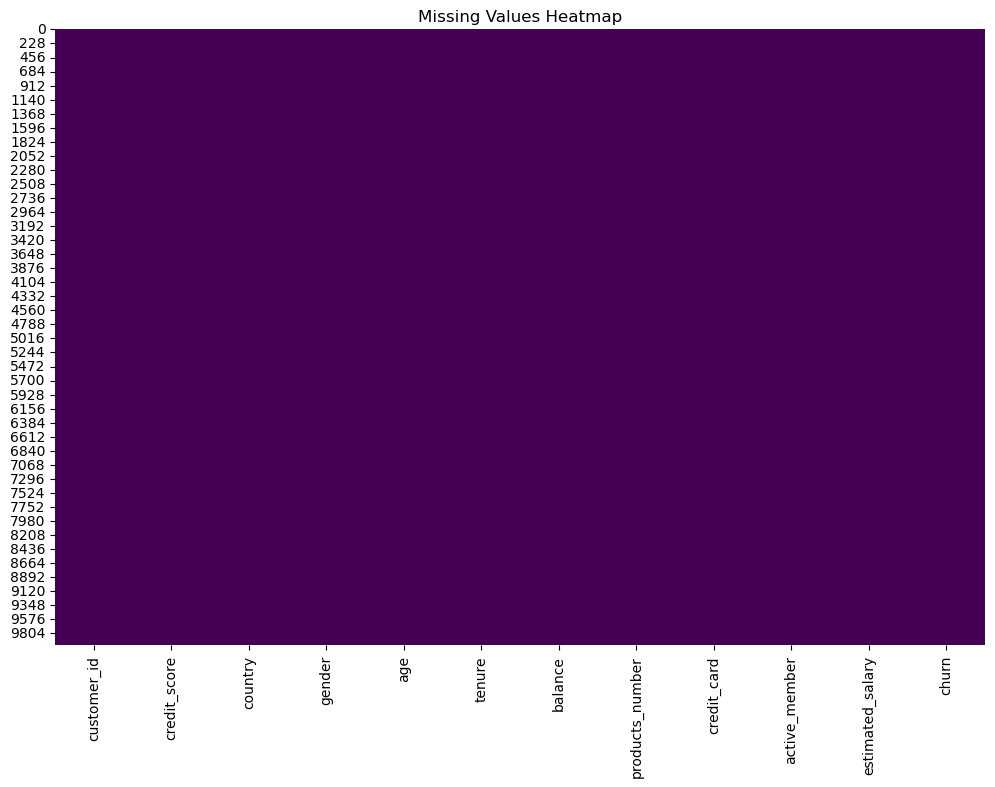

In [5]:
# Step 2: Missing Values Analysis
# ------------------------------------
# Perform Missing Values Analysis
missing_values_analyzer = SimpleMissingValuesAnalysis()
missing_values_analyzer.analyze(df)

### Insights  

#### **1. Dataset Overview:**  
- The dataset contains **10,000 entries** and **10 columns**.  
- **Data Types**: All columns are numerical (`int64` or `float64`) except for the target variable `churn`, which is binary.  

---

#### **2. Summary Statistics:**  
- **Numerical Features**:  
  - **Credit Score**:  
    - Mean: **650.53**, with a standard deviation of **96.65**.  
    - Range: **350 to 850**, covering poor to excellent credit scores.  
  - **Age**:  
    - Mean: **38.92 years**, indicating a middle-aged customer base.  
    - Range: **18 to 92 years**, showing a wide demographic spread.  
  - **Tenure**:  
    - Mean: **5 years**, with a range of **0 to 10 years**.  
    - Median: **5 years**, suggesting relatively stable customers.  
  - **Balance**:  
    - Mean: **76,485.89**, but with high variability (std: **62,397.40**).  
    - Minimum: **0** (some customers don’t maintain a balance).  
    - Maximum: **250,898.09**, indicating high-value customers.  
  - **Products Number**:  
    - Most customers own **1 or 2 products** (median: **1**, 75th percentile: **2**).  
    - Maximum: **4 products**, suggesting room for cross-selling opportunities.  
  - **Estimated Salary**:  
    - Mean: **100,090.24**, with a range from **11.58 to 199,992.48**.  
    - High standard deviation (**57,510.49**) highlights diverse customer income levels.  

- **Binary Features**:  
  - **Credit Card**:  
    - 70.55% of customers own a credit card, indicating widespread adoption.  
  - **Active Member**:  
    - 51.51% of customers are active members, showing a balanced split.  
  - **Churn**:  
    - 20.37% churn rate, meaning 1 in 5 customers leave the bank.  

---

#### **3. Key Observations:**  
- **Churn Rate**:  
  - A relatively high churn rate of **20.37%** emphasizes the need for targeted retention strategies.  
- **Customer Segmentation**:  
  - Most customers have good credit scores, moderate tenure, and own only 1 or 2 products.  
  - A significant proportion of customers maintain no balance, which could indicate low engagement.  
- **High Variability**:  
  - Features like balance and estimated salary show high variability, suggesting a diverse customer base.  

---


c:\Users\admin\OneDrive - Vidyalankar Polytechnic\Desktop\ML\ML PROJECTS\price prediction\analysis\analyze_src\univariate_analysis.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


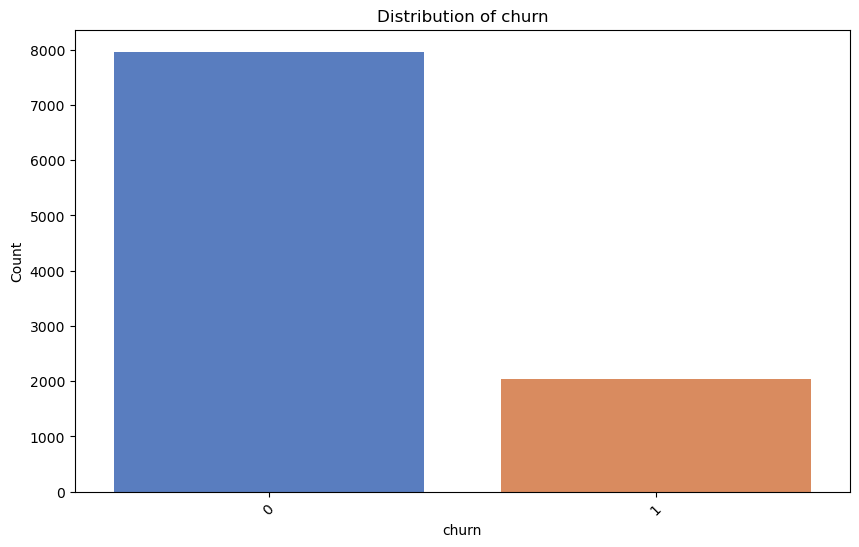

In [8]:
# Step 3: Univariate Analysis
# -----------------------------------
# Analyzing a Numerical Feature
univariate_analyzer = UnivariateAnalyzer(CategoricalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, 'churn')

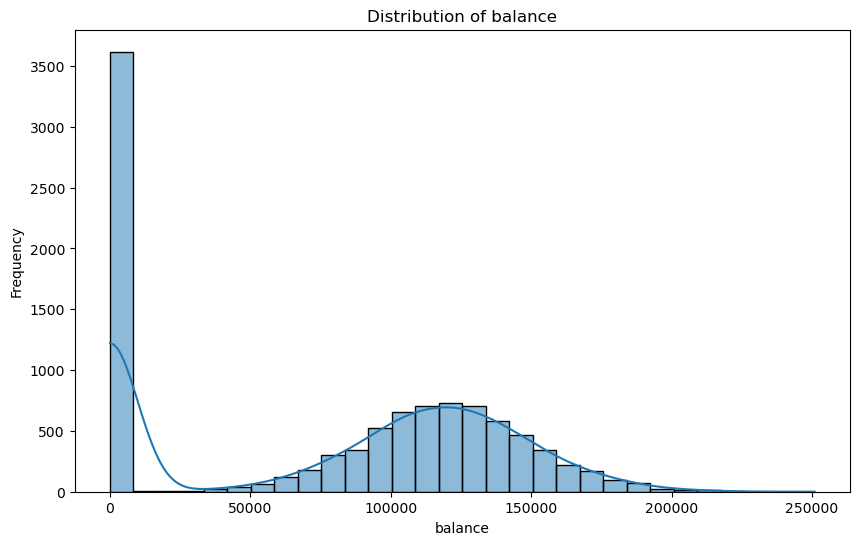

In [26]:
# Analyzing a Categorical Feature
univariate_analyzer.set_strategy(NumericalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, 'balance')


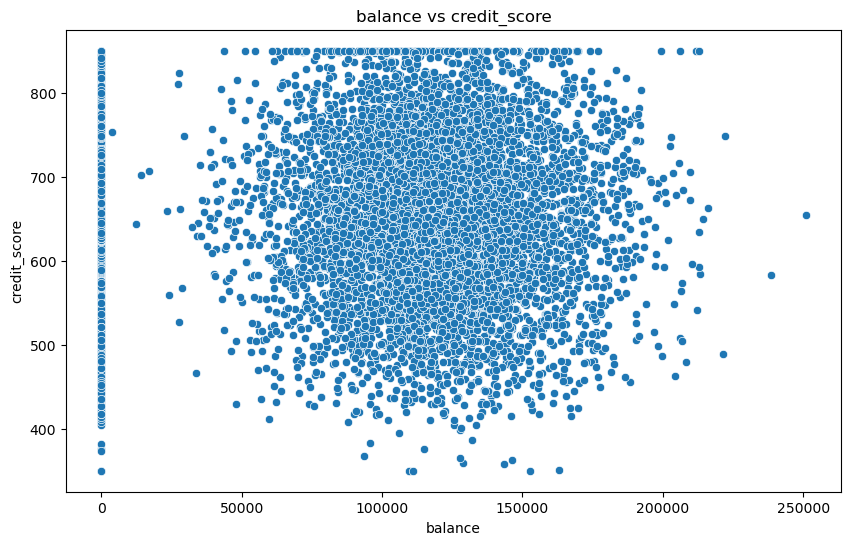

In [22]:
# Step 4: Bivariate Analysis
# -----------------------------------
# Analyzing the Relationship Between Two Numerical Features
bivariate_analyzer = BivariateAnalyzer(NumericalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df, 'balance', 'credit_score')


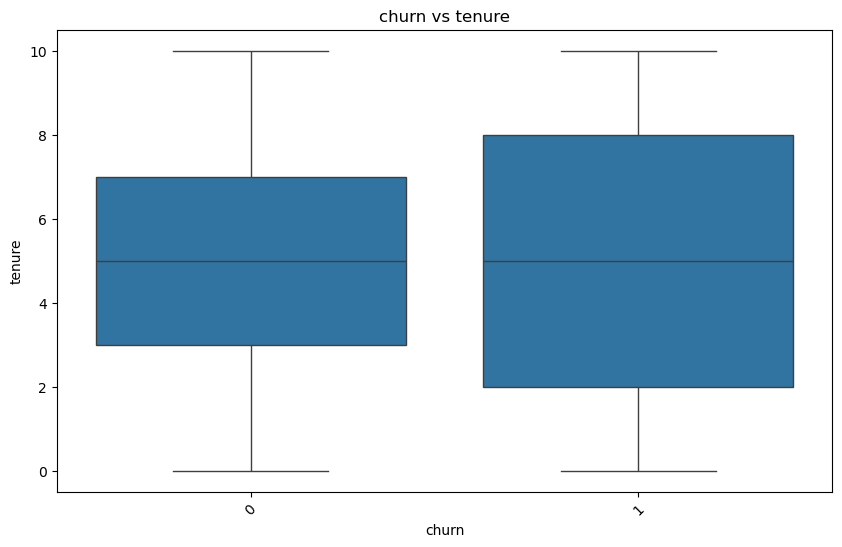

In [23]:
# Analyzing the Relationship Between a Categorical and a Numerical Feature
bivariate_analyzer.set_strategy(CategoricalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df,'churn', 'tenure')

### **Insights from Univariate and Bivariate Analysis**

#### **Step 3: Univariate Analysis**

- **Imbalance in Dataset**: More non-churned (7963) than churned (2037) customers.
- **Model Bias**: The model may predict the majority class (non-churned) more often, neglecting churned customers.
- **Unreliable Accuracy**: Accuracy might be high, but fails to reflect model performance on churned customers.
- **Evaluation Metrics**: Use precision, recall, F1-score, and ROC-AUC for better evaluation.
- **Solutions**:
  - Resample data (oversample minority or undersample majority).
  - Use SMOTE for synthetic data generation.


#### **Step 4: Bivariate Analysis**

1. **Credit Score and Balance (Numerical vs. Numerical)**:
   - **Insight**: There are multiple customers with zero balance in the account
   - **Implication**: The customers with zero balance customers have 13.78% of Churn Rate, Saving them is more profitable rather than paying high Acquisition Costs for new customers.

2. **Churn vs. Tenure (Categorical vs. Numerical)**:
   - **Insight**: Churned customers have a broader tenure range (2 to 8 years), which suggests that some long-term customers are leaving, which could be a concern. It indicates that even customers who have been with the bank for several years are at risk of churning.
   - **Implication**: The bank might be losing customers who have been loyal for a significant amount of time, which can lead to a loss of accumulated customer trust and lifetime value.

### **Summary**:

- **Data Imbalance**: The dataset has more non-churned (7963) customers than churned (2037), leading to potential model bias toward the majority class.
- **Model Evaluation**: Relying on accuracy may be misleading due to the class imbalance. It's important to use metrics like precision, recall, F1-score, and ROC-AUC for more reliable evaluation.
- **Retention of Zero-Balance Customers**: Customers with zero balance have a 13.78% churn rate, suggesting that retaining these customers is more cost-effective than acquiring new ones.
- **Churn and Tenure**: Long-term customers (2 to 8 years) are at risk of churning, highlighting the need for strategies to retain loyal customers.


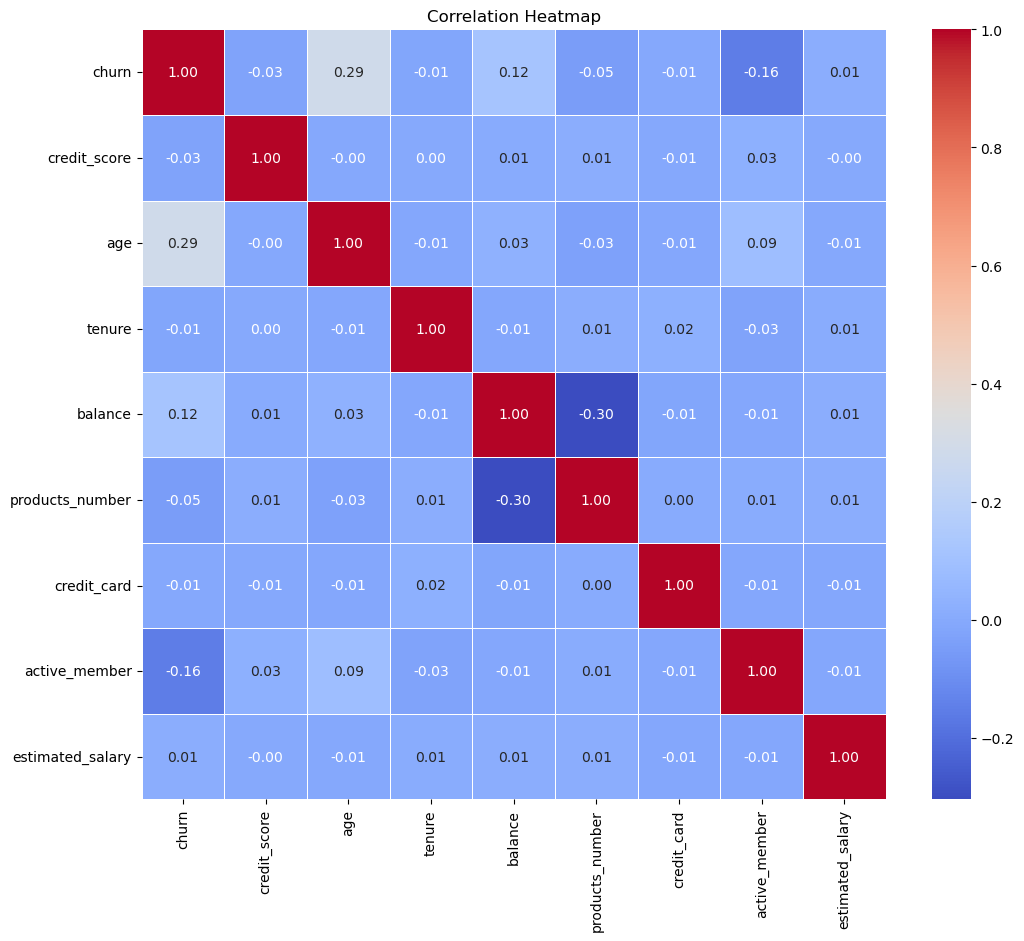

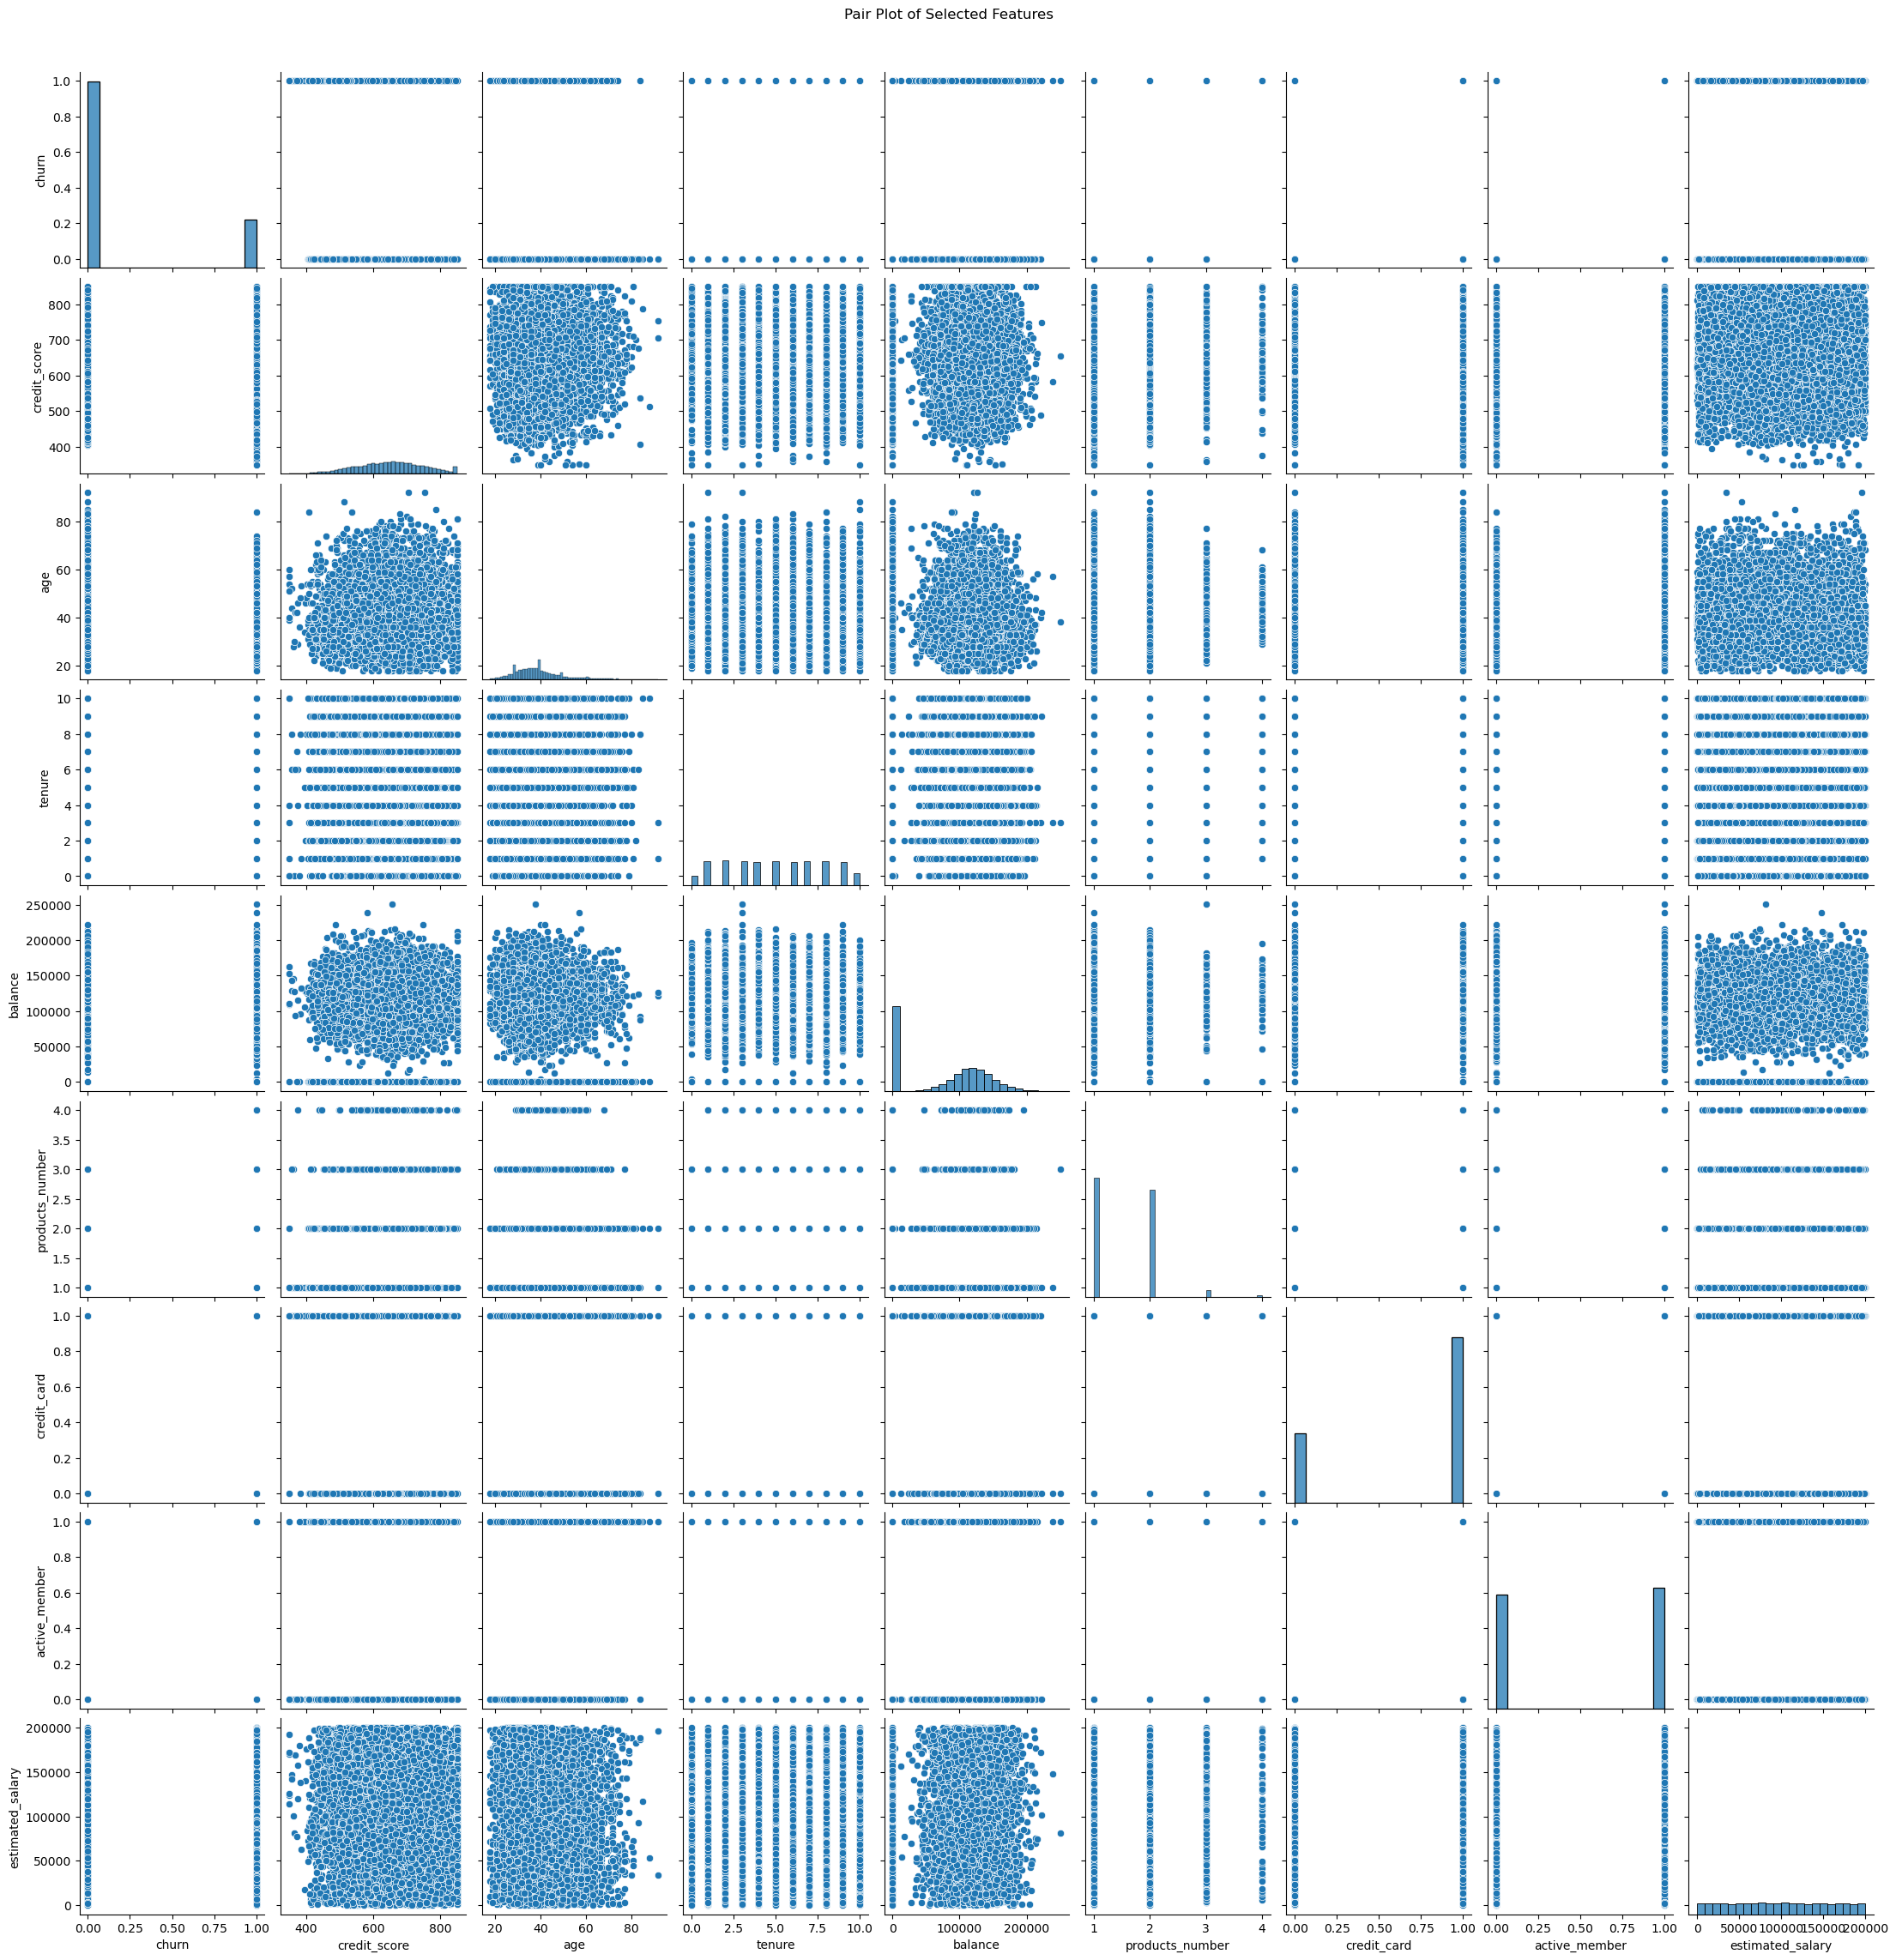

In [24]:

# Step 5: Multivariate Analysis
# ------------------------------
# Perform Multivariate Analysis

# Initialize the MultivariateAnalyzer with the SimpleMultivariateAnalysis strategy
multivariate_analyzer = SimpleMultivariateAnalysis()

# Select important features for the analysis
selected_features = df[["churn",
    "credit_score",
    "age",
    "tenure",
    "balance",
    "products_number",
    "credit_card",
    "active_member",
    "estimated_salary"
]]

# Execute the multivariate analysis
multivariate_analyzer.analyze(selected_features)


### **Insights from Multivariate Analysis**

#### **Correlation Heatmap:**
1. **Churn and Age**:
   - **Insight**: A high correlation between churn and age indicates that certain age groups might be more likely to churn, which can provide valuable insights into customer behavior.
   - **Implication**: 
    - Targeted Retention Strategies: If older or younger customers are more likely to churn, the bank can create targeted campaigns aimed at those specific groups to improve retention.
   - Feature Importance: Age may be a crucial feature in predictive models, and its influence on churn might help guide future marketing or service changes.

2. **Balance and products**:
   - **Insight**: A high correlation, this suggests that as customers have more products, their account balance tends to be higher, or vice versa.
   - **Implication**: 
   - Cross-Selling Potential-Customers with higher balances may be more likely to purchase additional products, so the bank might consider targeting higher-balance customers with more products.

### **Issues to Address:**

1. **Imbalanced Dataset**:
   - **Issue**: The dataset is highly imbalanced, with a significant number of non-churned customers (7963) compared to churned customers (2037).
   - **Action**: Resample the data by either oversampling the minority class (churned customers) or undersampling the majority class (non-churned customers). Alternatively, use SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic data for the minority class to balance the dataset.

2. **Model Bias**:
   - **Issue**: Due to the imbalanced dataset, the model might predict the majority class (non-churned) more often, neglecting churned customers.
   - **Action**: Implement techniques such as class weights or cost-sensitive learning to ensure the model pays more attention to the minority class (churned customers).

3. **Evaluation Metrics**:
   - **Issue**: Accuracy may be high due to the imbalance, but it fails to reflect model performance on churned customers.
   - **Action**: Use alternative evaluation metrics like precision, recall, F1-score, and ROC-AUC to get a more balanced view of the model’s performance, especially for churn prediction.

4. **Churn vs. Age (High Correlation)**:
   - **Issue**: A high correlation between churn and age suggests that age might be a significant predictor of churn, but this feature's impact should be analyzed further.
   - **Action**: Create age bins to group customers and analyze churn rates within different age groups. Consider incorporating age as a feature in predictive models and exploring targeted marketing strategies based on age.

5. **Balance and Products (Moderate Correlation)**:
   - **Issue**: A moderate correlation between balance and products suggests that customers with higher balances tend to have more products, which could be a key factor in cross-selling.
   - **Action**: Analyze customer segments with higher balances and more products. Use this insight to target higher-balance customers with additional products, optimizing the bank’s cross-selling strategies.

6. **Churn and Tenure (Broad Range)**:
   - **Issue**: Churned customers have a broader tenure range (2 to 8 years), indicating that even long-term customers are at risk of churning.
   - **Action**: Develop retention strategies focused on long-term customers. Use tenure as a feature in predictive models to assess the risk of churn among loyal customers.

7. **Zero Balance Customers with High Churn Rate**:
   - **Issue**: Customers with a zero balance have a churn rate of 13.78%, which indicates that saving these customers might be more cost-effective than acquiring new customers.
   - **Action**: Identify the reasons why customers with zero balances are churning and explore targeted retention campaigns to win them back, reducing churn and avoiding high acquisition costs.
